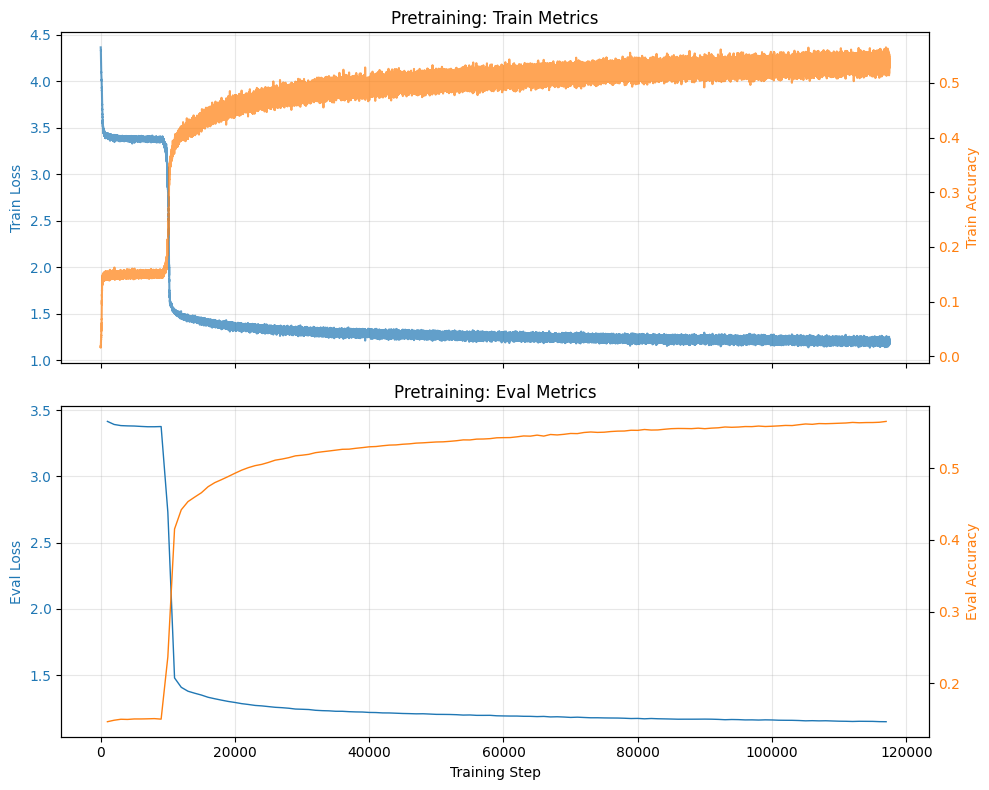

Saved to /home/bauerste/Methylbert_methylation_encoding/methylbert/myNotebooks/loss_curves.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

train_path = "/home/bauerste/Methylbert_methylation_encoding/pretrained_model_2gpu/train.csv"
eval_path = "/home/bauerste/Methylbert_methylation_encoding/pretrained_model_2gpu/eval.csv"
out_path = "/home/bauerste/Methylbert_methylation_encoding/methylbert/myNotebooks/loss_curves.png"

# Read once. on_bad_lines="skip" helps if the writer is currently appending a partial row.
train = pd.read_csv(train_path, sep="\t", on_bad_lines="skip")
eval_ = pd.read_csv(eval_path, sep="\t", on_bad_lines="skip")

# Drop rows with missing values caused by partial writes
train = train.dropna(subset=["step", "loss", "acc"])
eval_ = eval_.dropna(subset=["step", "test_loss", "test_acc"])

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# --- Train ---
ax = axes[0]
ax.plot(train["step"], train["loss"], color="tab:blue", label="Train Loss", linewidth=1)
ax.set_ylabel("Train Loss", color="tab:blue")
ax.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax.twinx()
ax2.plot(train["step"], train["acc"], color="tab:orange", label="Train Accuracy", linewidth=1)
ax2.set_ylabel("Train Accuracy", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")

ax.set_title("Pretraining: Train Metrics")
ax.grid(alpha=0.3)

# --- Eval ---
ax = axes[1]
ax.plot(eval_["step"], eval_["test_loss"], color="tab:blue", label="Eval Loss", linewidth=1)
ax.set_ylabel("Eval Loss", color="tab:blue")
ax.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax.twinx()
ax2.plot(eval_["step"], eval_["test_acc"], color="tab:orange", label="Eval Accuracy", linewidth=1)
ax2.set_ylabel("Eval Accuracy", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")

ax.set_xlabel("Training Step")
ax.set_title("Pretraining: Eval Metrics")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"Saved to {out_path}")